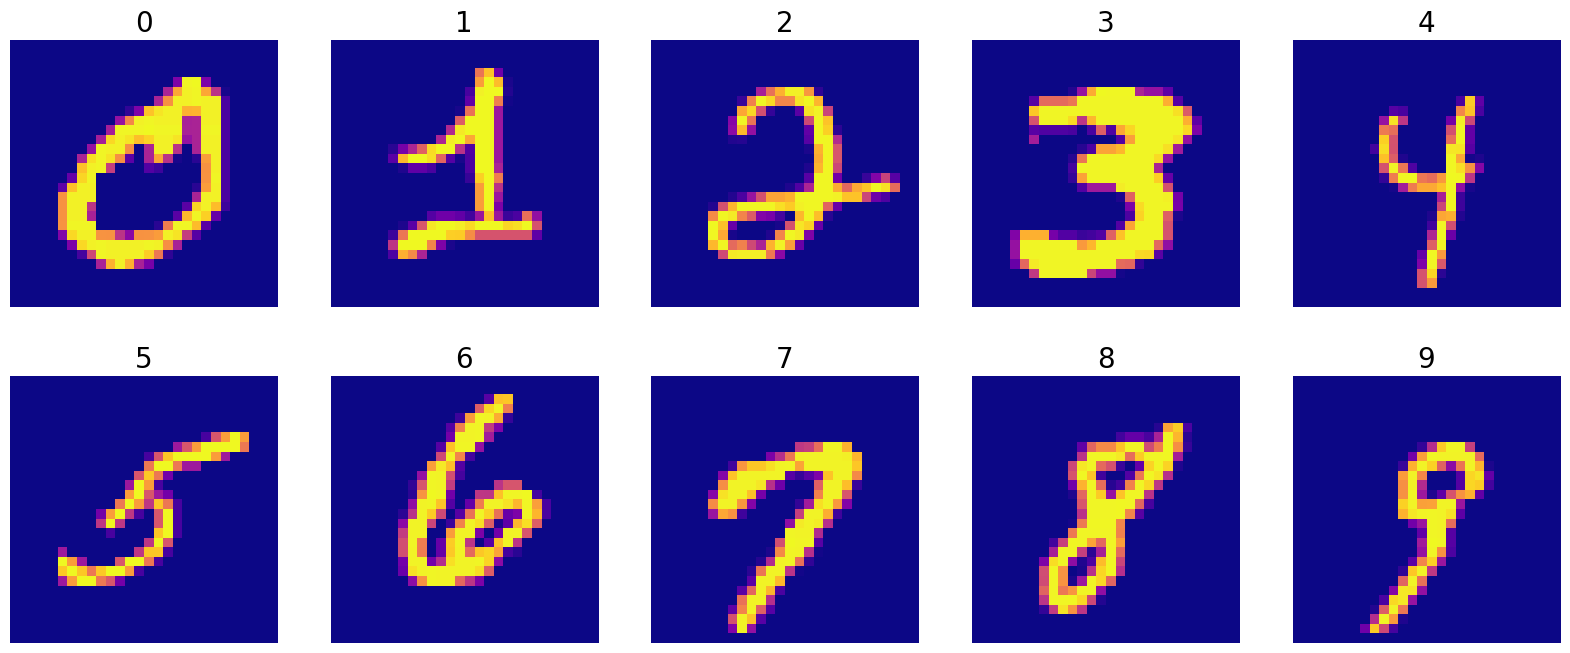

In [1]:
# Question 3)
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
from sklearn import svm
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

def plot_digits(images,
    n_rows = 2,
    n_cols = 5,
    fig_shape = (20,8),
    indexes = [0,1,2,3,4,5,6,7,8,9],
    img_shape = (28,28),
    labels = [0,1,2,3,4,5,6,7,8,9]):
    fig, axs = plt.subplots(n_rows, n_cols, figsize = fig_shape)
    ind = np.array(indexes).reshape(n_rows, n_cols)
    if labels:
        plt_labels = np.array(labels).reshape(n_rows, n_cols)
    for i in range(0,n_rows):
        for j in range(0,n_cols):
            if labels:
                axs[i,j].set_title(plt_labels[i,j], fontsize = 20)
            axs[i,j].imshow((images[ind[i,j]].reshape(img_shape)), cmap = "plasma")
            axs[i,j].axis('off')
mnist = fetch_openml("mnist_784") # Baixar os dados
X, y = mnist.data.to_numpy(), mnist.target.to_numpy()
X = X/255 # Colocar as features em [0, 1]
# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Plot dos digítos
plot_digits(X,n_rows = 2, n_cols = 5, indexes = [21, 24, 16, 27, 26, 35, 13, 15, 17, 19])


In [2]:
# (a) Treine cada um destes modelos nos dados de treino e calcule a acurácia no conjunto de treino e de teste. 
# Compare a acurácia e o tempo (em segundos) para treinar e o tempo para gerar previsões obtido nos modelos vistos 
# na primeira parte do curso (NB, LDA, QDA, Regressão Logística e KNN) com os vistos na segunda parte (SVM, random forests 
# e redes neurais). Quais têm melhor acurácia? Quais rodam mais rápido?
from sklearn.metrics import accuracy_score
import time
nb = BernoulliNB(force_alpha=True) # Naive Bayes com features bernoulli
lda = LinearDiscriminantAnalysis() # LDA
qda = QuadraticDiscriminantAnalysis(reg_param=0.01) # QDA 
lr = LogisticRegression(random_state=42) # Regressão Logística
knn = KNeighborsClassifier(n_neighbors=6) # kNN com k = 6
svc = svm.SVC(gamma="scale",class_weight="balanced",C=100) # SVM
rf = RandomForestClassifier(max_depth=30, random_state=0, n_estimators = 100) # Random forest
nn = MLPClassifier(random_state=42, hidden_layer_sizes = [100],max_iter=300) # Rede neural

models = [nb, lda, qda, lr, knn, svc, rf, nn]


yhats = []
accuracy = []
time_train = []
time_test = []
i = 0 
for model in models:    
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    time_train.append(end_time-start_time)
    
    start_time = time.time()
    yhat = model.predict(X_test)
    end_time = time.time()
    time_test.append(end_time-start_time)

    yhats.append(yhat)
    accuracy.append(accuracy_score(y_true=y_test, y_pred=yhat))
    print("model", models[i].__class__.__name__, 'yhats:', yhats[i], 'accuracy:', accuracy[i], 'time_train:', time_train[i], 'time_test:', time_test[i])
    i += 1



print("Observação: para a convergência do modelo de QDA, foi necessário adicionar um parâmetro de regularização reg_param = 0.01.")
print("Além disso, os dados não foram normalizados, dada a escala semelhante das features.")

model BernoulliNB yhats: ['8' '4' '5' ... '1' '7' '1'] accuracy: 0.8348571428571429 time_train: 1.0701327323913574 time_test: 0.3053932189941406
model LinearDiscriminantAnalysis yhats: ['8' '4' '5' ... '2' '7' '1'] accuracy: 0.8677142857142857 time_train: 9.183963060379028 time_test: 0.05253243446350098
model QuadraticDiscriminantAnalysis yhats: ['8' '4' '8' ... '2' '7' '1'] accuracy: 0.9428571428571428 time_train: 8.068514585494995 time_test: 4.2919957637786865


c:\Users\User\miniconda3\envs\ml_impa\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


model LogisticRegression yhats: ['8' '4' '5' ... '2' '7' '1'] accuracy: 0.9202857142857143 time_train: 13.422965049743652 time_test: 0.030497312545776367
model KNeighborsClassifier yhats: ['8' '4' '8' ... '2' '7' '1'] accuracy: 0.969 time_train: 0.2681601047515869 time_test: 33.9865984916687
model SVC yhats: ['8' '4' '8' ... '2' '7' '1'] accuracy: 0.9824285714285714 time_train: 212.1858937740326 time_test: 143.9071662425995
model RandomForestClassifier yhats: ['8' '4' '8' ... '2' '7' '1'] accuracy: 0.9673571428571428 time_train: 58.207008600234985 time_test: 0.6064052581787109
model MLPClassifier yhats: ['8' '4' '8' ... '2' '7' '1'] accuracy: 0.9755 time_train: 109.0177321434021 time_test: 0.1208488941192627
Observação: para a convergência do modelo de QDA, foi necessário adicionar um parâmetro de regularização reg_param = 0.01.
Além disso, os dados não foram normalizados, dada a escala semelhante das features.


Cada imagem representa a probabilidade dos pixeis da imagem de pertecerem à respectiva classe, sendo que valores altos indicam pixeis recorrentes para a classe.O produto entre este vetor e a entrada indicará a probabilidade da entrada ser pertencente à classe e será utilizada para classificação. A interpretação da imagem é simples e permite a reconstituição do dígito ao qual a classe referencia.


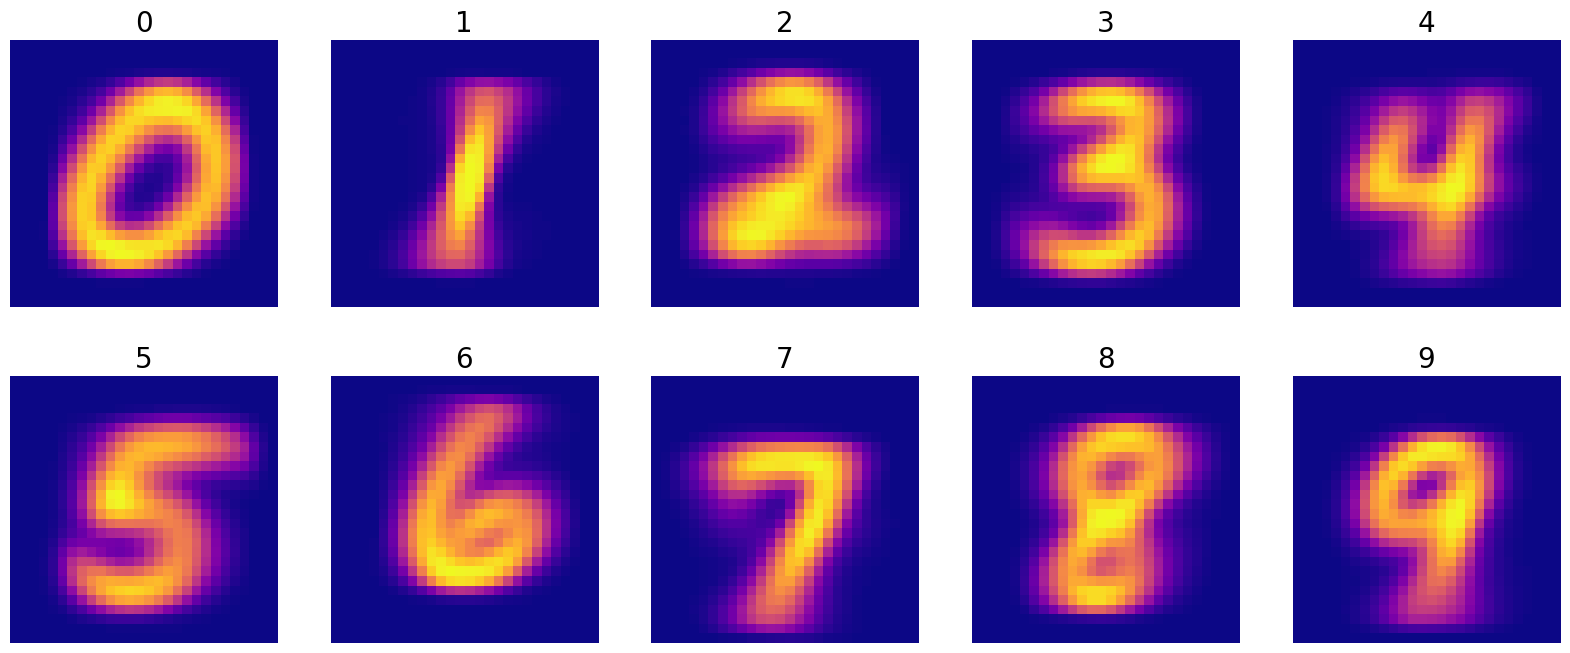

In [3]:
# Para cada um dos gráficos gerados pelos códigos abaixo, explique o que está sendo mostrado,
# como isso se relaciona com as previsões do modelo em questão e se é possível interpretar com
# facilidade o que está acontecendo.
    
# (i)
nb_params = {}
for i in range(10):
    nb_params[i] = np.exp(nb.feature_log_prob_[i])

plot_digits(nb_params)

print("Cada imagem representa a probabilidade dos pixeis da imagem de pertecerem à respectiva classe, sendo que valores altos indicam pixeis recorrentes para a classe." \
"O produto entre este vetor e a entrada indicará a probabilidade da entrada ser pertencente à classe e será utilizada para classificação. A interpretação da imagem " \
"é simples e permite a reconstituição do dígito ao qual a classe referencia.")

Cada uma das imagens é a média da respectiva classe no espaço de entrada. Essa imagem seria equivalente a uma amostra média, ponto central em relaçãoàs demais amostras da classe. As previsões do modelo baseiam-se em uma métrica de similaridade  da entrada em relação a cada uma dessas médias. É possivel interpretarcom facilidade a classe relacionada a cada imagem.


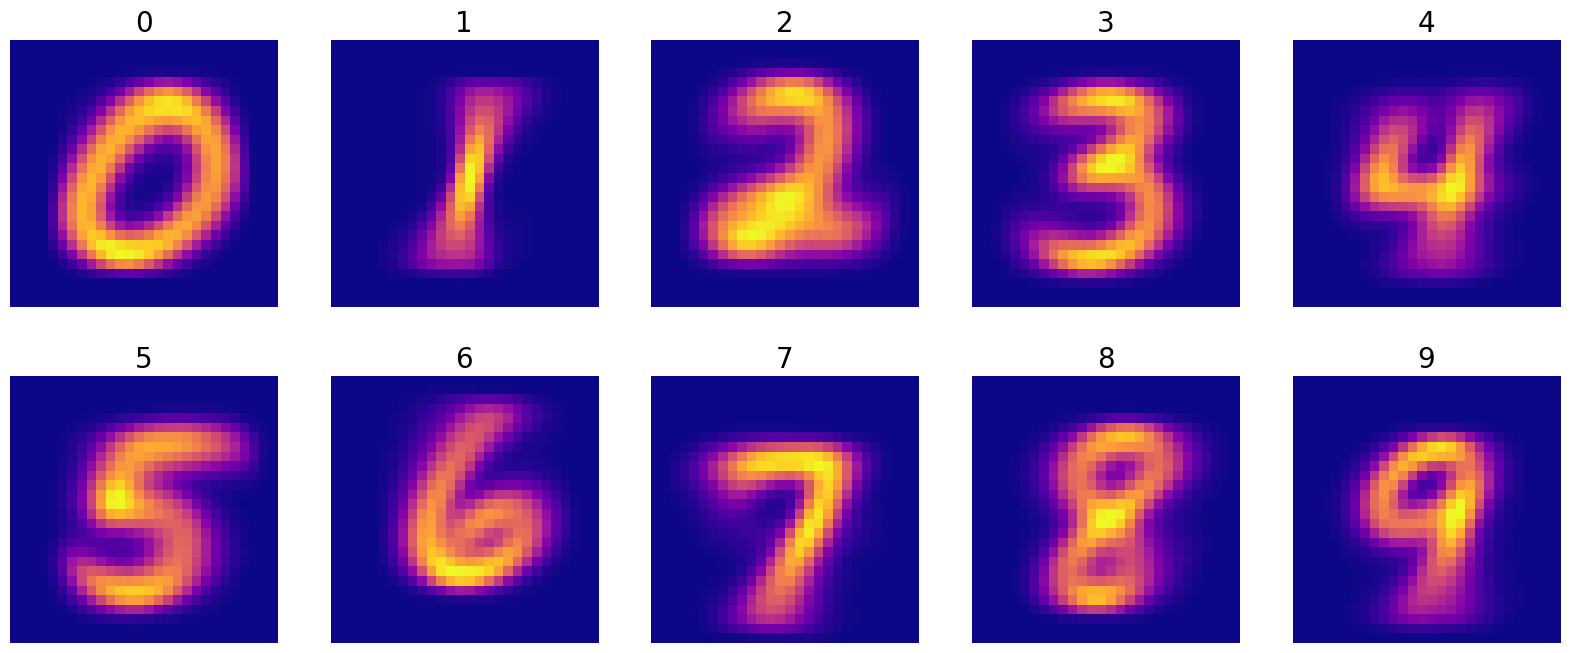

In [4]:
# (ii)
lda_params = {}
for i in range(10):
    lda_params[i] = lda.means_[i]


plot_digits(lda_params)
print('Cada uma das imagens é a média da respectiva classe no espaço de entrada. Essa imagem seria equivalente a uma amostra média, ponto central em relação' \
'às demais amostras da classe. As previsões do modelo baseiam-se em uma métrica de similaridade  da entrada em relação a cada uma dessas médias. É possivel interpretar' \
'com facilidade a classe relacionada a cada imagem.')

'Ainda mantemos uma interpretação válida de cada classe por meio da imagem, apesar de menos clara caso comparemos com as imagens dos modelos anteriores'

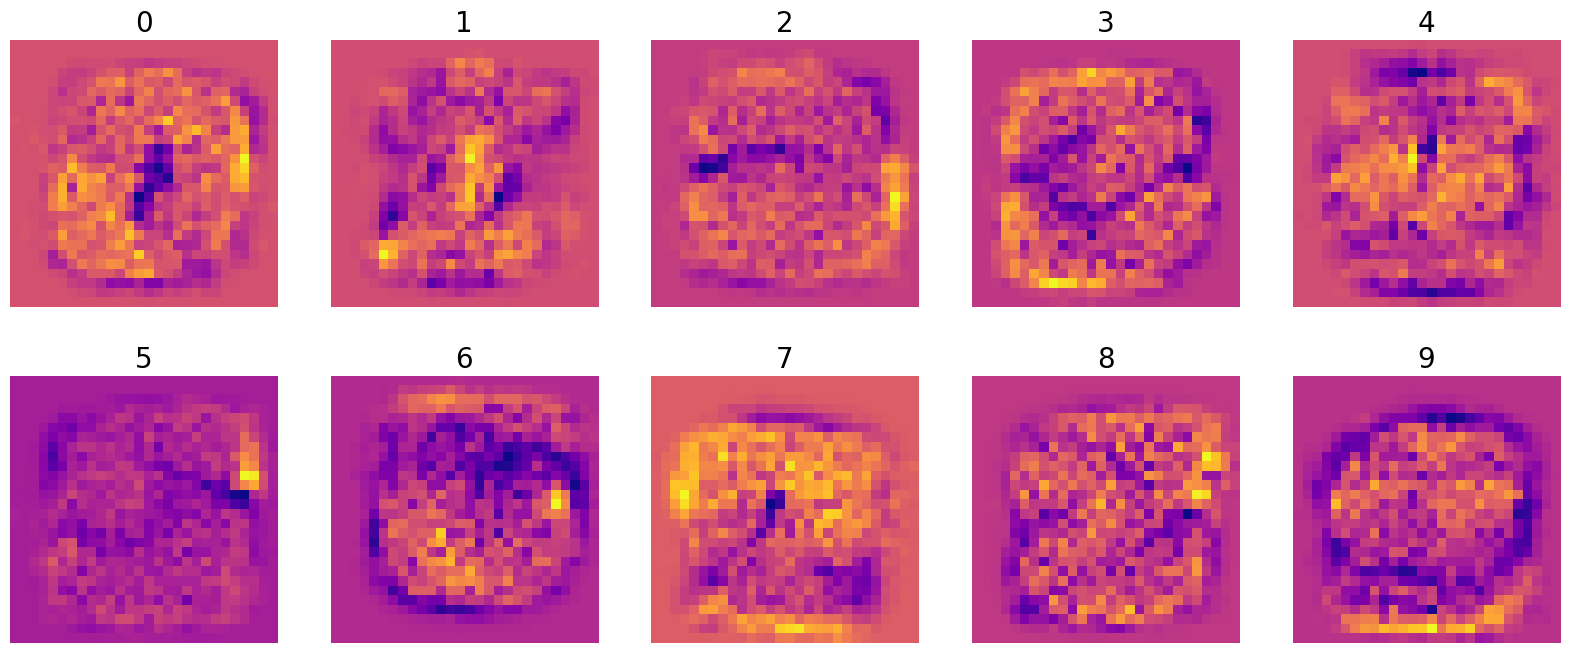

In [5]:
# (iii) 
log_reg_params = {}
for i in range(10):
    log_reg_params[i] = lr.coef_[i]

plot_digits(log_reg_params)
"A imagem representa o coeficiente da rede. Ao multiplicarmos pela entrada, teremos o logarítmo probabilidade da amostra pertencer à classe sobre a probabilidade dela pertencer "
"à classe de referência. A imagem mostrada é a resposta do modelo a uma matriz de 1's. Isso pode ser interpretado com a contribuição de cada pixel para a probabilidade final."
"Ainda mantemos uma interpretação válida de cada classe por meio da imagem, apesar de menos clara caso comparemos com as imagens dos modelos anteriores"

'ainda está clara qual a região mais importante para a classificação.'

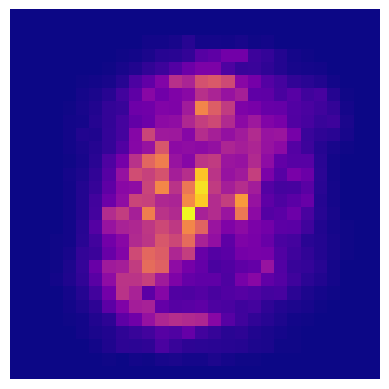

In [6]:
# (iv) 
rf_params = rf.feature_importances_.reshape(28, 28)

plt.axis("off")
plt.imshow(rf_params, cmap="plasma")


"A imagem representa a importância de cada pixel para o modelo, baseado ena média do decaímneto de uma métrica de impureza, no caso, o coeficiente de Gini."
"Valores altos indicam que aquela feature foi capaz de auxiliar na distinção entre as classes. Nesse caso, perde-se a interpretação individual das classes, entretanto"
"ainda está clara qual a região mais importante para a classificação."

In [7]:
# (v) a-  
nn_params_1 = {}
for i in range(100):
    nn_params_1[i] = nn.coefs_[0][:, i]

indexes = list(range(100))

plot_digits(
    nn_params_1,
    n_rows=10,
    n_cols=10,
    fig_shape=(100, 100),
    indexes=indexes,
    img_shape=(28, 28),
    labels=None
)

print("Cada imagem representa os pesos que ligam a entrada a cada um dos neurõnios da camada oculta. Eles são a transformação linear da entrada antes da " \
"primeira função de ativaçãoe podem ser interpretados como parte de uma engenharia de feature. A interpretabilidade já se perdeu completamente," \
"tanto pela alta quantidade de neurônios quanto pela dificuldade de encontrar valor semântico em cada transformação.")

Cada imagem representa os pesos que ligam a entrada a cada um dos neurõnios da camada oculta. Eles são a transformação linear da entrada antes da primeira função de ativaçãoe podem ser interpretados como parte de uma engenharia de feature. A interpretabilidade já se perdeu completamente,tanto pela alta quantidade de neurônios quanto pela dificuldade de encontrar valor semântico em cada transformação.


Cada imagem representa os pesos que ligam a camada escondida da rede à camada de saída, em que uma regressão logística será realizada. Seria semelhante ao que ocorreno modelo de regressão logística do item anterios. Entretanto, como o espaço de features é a projeção da entrada na camada intermediária, a interpretação se perde, não podendorelacionar cada classe ao numeral correspondente.


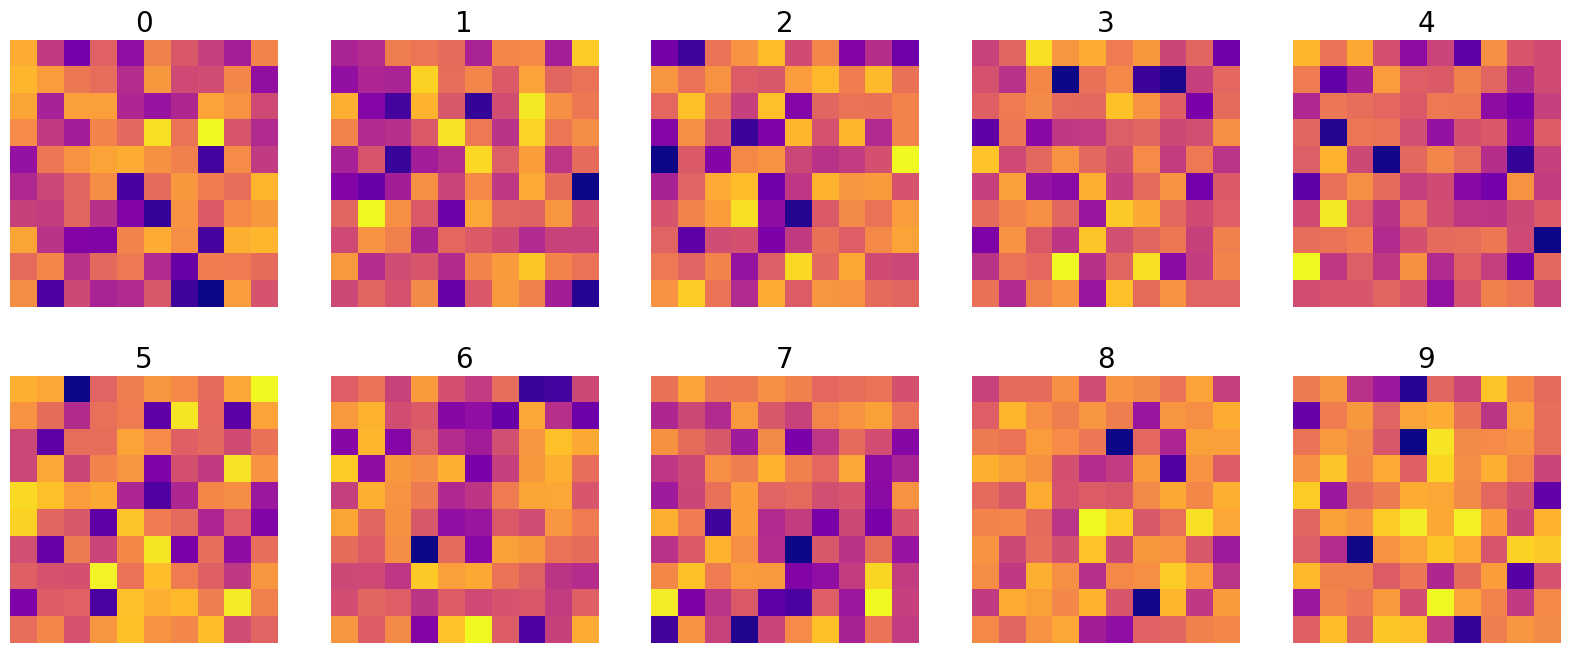

In [8]:
# (v) b-
nn_params_2 = {}
for i in range(10):
    nn_params_2[i] = nn.coefs_[1][:, i]

plot_digits(
    nn_params_2,
    n_rows=2,
    n_cols=5,
    fig_shape=(20, 8),
    img_shape=(10, 10)
)

print("Cada imagem representa os pesos que ligam a camada escondida da rede à camada de saída, em que uma regressão logística será realizada. Seria semelhante ao que ocorre" \
"no modelo de regressão logística do item anterios. Entretanto, como o espaço de features é a projeção da entrada na camada intermediária, a interpretação se perde, não podendo" \
"relacionar cada classe ao numeral correspondente.")

In [9]:
#(c) Gere a matriz de confusão para as previsões do Naive Bayes no conjunto de teste. Veja para cada classe qual é o erro mais comum e dê uma possível explicação.
cm = confusion_matrix(y_true=y_test, y_pred=yhats[0])
mask = 1 - np.identity(cm.shape[0])
error_matrix = np.multiply(cm,mask)

error_perc = error_matrix.sum(axis=1) / cm.sum(axis=1)
print(cm,'\n')

print(error_perc,'\n')

value, count = np.unique(y_train, return_counts=True)
print('Contagem da classe nos dados de treino\n',np.concatenate((value,count)).reshape(2,10))

print(f'\nA classe mais errada foi a {np.argmax(error_perc)}.Nota-se pela matriz de confusão'\
      'que o parte considerável dos erros para esta classe ocorreram pois o modelo previu 1, 3 e 8. Provavelmente isso acontece pela semelhança ' \
      'dos dígitos 5, 3 e 8 e pelo desbalanceamento da classe 1 nos dados de treino, que foi a mais frequente.')





[[1198    1    6   13    3   63   31    1   25    2]
 [   0 1540    8    8    1   18    3    1   17    4]
 [  17   25 1133   39   29    7   57   12   55    6]
 [   8   36   67 1148    3   31   13   22   60   45]
 [   4    7    8    0 1042    8   22    6   26  172]
 [  31   22    9  190   38  906   25    7   17   28]
 [  15   42   32    2   19   33 1250    0    3    0]
 [   8   28   11    5   34    3    0 1274   30  110]
 [  17   55   23  103   14   45    6    6 1033   55]
 [  11   26    8   11  101    7    0   55   37 1164]] 

[0.10796724 0.0375     0.17898551 0.19888346 0.1953668  0.28829537
 0.10458453 0.15236194 0.23876197 0.18028169] 

Contagem da classe nos dados de treino
 [['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
 [5560 6277 5610 5708 5529 5040 5480 5790 5468 5538]]

A classe mais errada foi a 5.Nota-se pela matriz de confusãoque o parte considerável dos erros para esta classe ocorreram pois o modelo previu 1, 3 e 8. Provavelmente isso acontece pela semelhança dos dígitos 5, 3 